In [1]:
import pandas as pd
import matplotlib.pyplot as mp
import seaborn as sb
import os

os.chdir(r'C:\Users\cebal\OneDrive\Documentos\Grandes Bases de Datos I')

from sklearn.cluster import KMeans

dataset = pd.read_csv('iris.csv')
dataset.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [4]:
# seleccionamos las variables que son numericas
fields = dataset.iloc[:, [0,1,2,3]].values
print(fields)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [5]:
import warnings
warnings.filterwarnings('ignore')

In [6]:
wcss = []
for index in range(1,11):
    kmeans = KMeans(n_clusters = index, init = "k-means++", random_state = 2)
    kmeans.fit(fields)
    
    wcss.append(kmeans.inertia_)

Text(0, 0.5, 'WCSS')

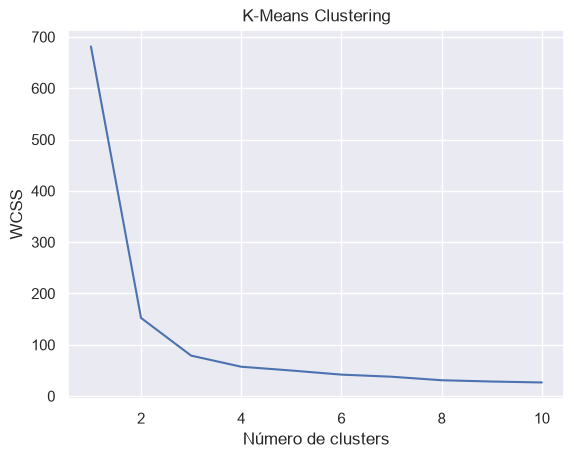

In [7]:
# Graficación del "Codo de Jambu"
sb.set()
mp.plot(range(1,11), wcss)
mp.title("K-Means Clustering")
mp.xlabel("Número de clusters")
mp.ylabel("WCSS") # Weighted cluster sum of squares

In [ ]:
# por lo que se nota una reduccion considerable del WCSS conforme aumenta el numero de Clusters.
# por lo que mediante el grafico de codo se puede considerar k= 3 como un numero adecuado de 
# clusters.

In [9]:
# Aplicamos el algoritmo K-Medias utilizando el número óptimo
# de clusters obtenido mediante el gráfico de Codo y Silhouette.
kmeans = KMeans(n_clusters = 4, init = "k-means++", random_state = 42)

# Asignamos cada observación al cluster correspondiente.
cluster_values = kmeans.fit_predict(fields)
print(cluster_values)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 2 0 2 0 2 0 2 2 2 2 0 2 0 2 2 0 2 0 2 0 0
 0 0 0 0 0 2 2 2 2 0 2 0 0 0 2 2 2 0 2 2 2 2 2 0 2 2 3 0 3 0 3 3 2 3 3 3 0
 0 3 0 0 0 0 3 3 0 3 0 3 0 3 3 0 0 0 3 3 3 0 0 0 3 3 0 0 3 3 0 0 3 3 0 0 0
 0 0]


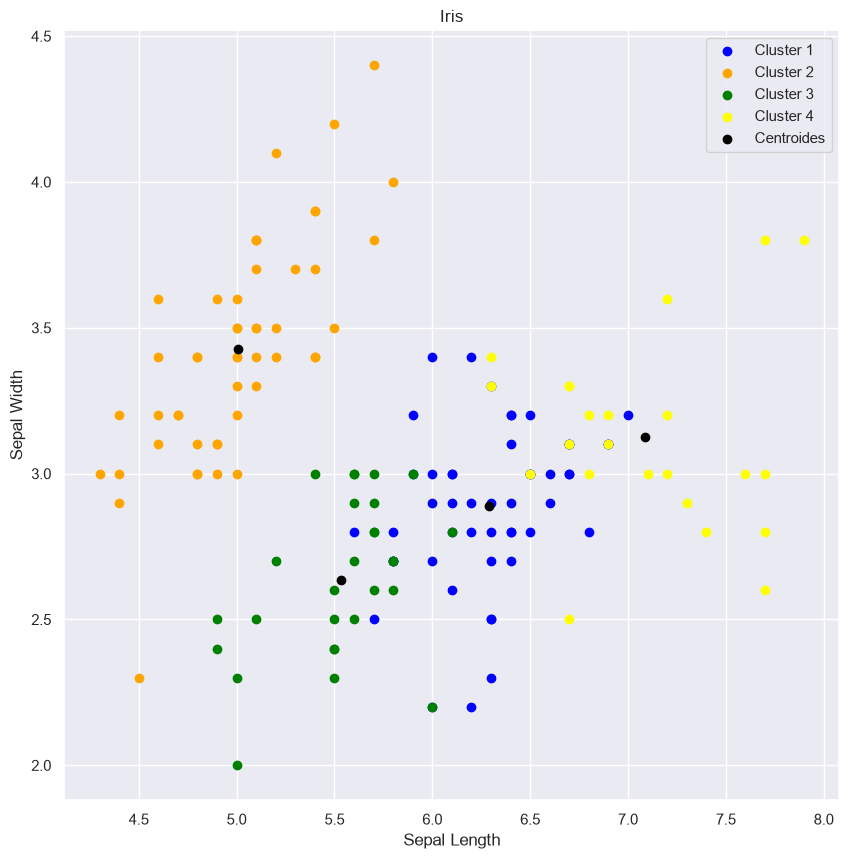

In [11]:
mp.figure(figsize = (10,10))
mp.scatter(fields[cluster_values == 0,0], fields[cluster_values == 0,1], 
           c = 'blue', label = 'Cluster 1')
mp.scatter(fields[cluster_values == 1,0], fields[cluster_values == 1,1], 
           c = 'orange', label = 'Cluster 2')
mp.scatter(fields[cluster_values == 2,0], fields[cluster_values == 2,1], 
           c = 'green', label = 'Cluster 3')
mp.scatter(fields[cluster_values == 3,0],  fields[cluster_values == 3,1], 
           c = 'yellow', label = 'Cluster 4')
mp.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], 
           c = 'black', label = 'Centroides')

mp.title("Iris")
mp.xlabel("Sepal Length")
mp.ylabel("Sepal Width")
mp.legend()

In [12]:
# Criterio de Silueta ("Silhouette")
from sklearn import datasets
from sklearn.metrics import silhouette_score

In [13]:
# Seleccionamos las cuatro variables numéricas de la base original.
X = dataset.iloc[:, [0,1,2,3]].to_numpy()
for j in range(2,11):
    kmeans = KMeans(n_clusters = j, random_state = 42)
    kmeans.fit_predict(X)
    score = silhouette_score(X, kmeans.labels_, metric = 'euclidean')
    print("Score Silhouette:", "k =", j, ",", score)

Score Silhouette: k = 2 , 0.6810461692117465
Score Silhouette: k = 3 , 0.5511916046195927
Score Silhouette: k = 4 , 0.49764331793219296
Score Silhouette: k = 5 , 0.4930804067193529
Score Silhouette: k = 6 , 0.36784649847122536
Score Silhouette: k = 7 , 0.3542978877198859
Score Silhouette: k = 8 , 0.34467972180562056
Score Silhouette: k = 9 , 0.31558878533897866
Score Silhouette: k = 10 , 0.3014143745325154


In [ ]:
# en este caso el Silhoutte con un valor mayor es el de k = 2

In [14]:
fields2 = dataset.iloc[:, [0,1,2,3]].values
print(fields2)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [15]:
# Inciso 3
fields2 = dataset.iloc[:, [0,1,2,3]].values
print(fields2)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [16]:
from sklearn import decomposition
pca = decomposition.PCA(n_components = 2)
pca.fit(fields2)

fields2 = pca.transform(fields2)
fields2

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451],
       [-2.28085963,  0.74133045],
       [-2.82053775, -0.08946138],
       [-2.62614497,  0.16338496],
       [-2.88638273, -0.57831175],
       [-2.6727558 , -0.11377425],
       [-2.50694709,  0.6450689 ],
       [-2.61275523,  0.01472994],
       [-2.78610927, -0.235112  ],
       [-3.22380374, -0.51139459],
       [-2.64475039,  1.17876464],
       [-2.38603903,  1.33806233],
       [-2.62352788,  0.81067951],
       [-2.64829671,  0.31184914],
       [-2.19982032,  0.87283904],
       [-2.5879864 ,  0.51356031],
       [-2.31025622,  0.39134594],
       [-2.54370523,  0.43299606],
       [-3.21593942,  0.13346807],
       [-2.30273318,  0.09870885],
       [-2.35575405, -0.03728186],
       [-2.50666891, -0.14601688],
       [-2.46882007,  0.13095149],
       [-2.56231991,  0.36771886],
       [-2.63953472,

In [17]:
wcss2 = []
for index in range(1,11):
    
    kmeans = KMeans(n_clusters = index,
                    init = "k-means++",
                    random_state = 2)
    kmeans.fit(fields2)
    wcss2.append(kmeans.inertia_)

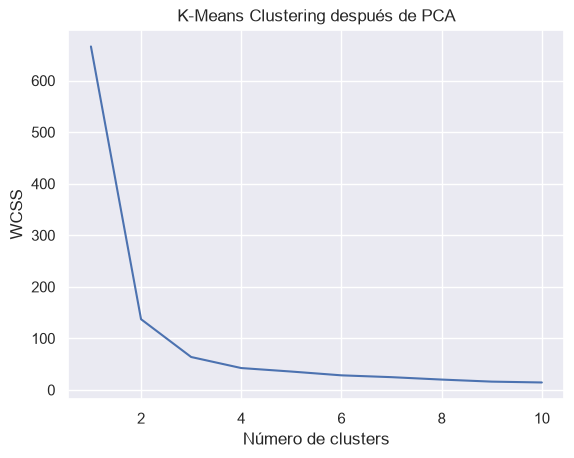

In [18]:
# Graficamos 
sb.set()
mp.plot(range(1,11), wcss2)
mp.title("K-Means Clustering después de PCA")
mp.xlabel("Número de clusters")
mp.ylabel("WCSS")

mp.show()

In [19]:
# Criterio de Silueta ("Silhouette") después de PCA
for j in range(2,11):
    kmeans = KMeans(n_clusters = j, random_state = 42)
    kmeans.fit_predict(fields2)
    score = silhouette_score(fields2, kmeans.labels_, metric = 'euclidean')
    print("Score Silhouette:", "k =", j, ",", score)

Score Silhouette: k = 2 , 0.7056703225102109
Score Silhouette: k = 3 , 0.5976764219547994
Score Silhouette: k = 4 , 0.5577409232246783
Score Silhouette: k = 5 , 0.5100407194899199
Score Silhouette: k = 6 , 0.40319738737442673
Score Silhouette: k = 7 , 0.3868263997713608
Score Silhouette: k = 8 , 0.44076033249654045
Score Silhouette: k = 9 , 0.4020143876366366
Score Silhouette: k = 10 , 0.41588658017532376


In [ ]:
# el numero de clusters recomendado por Silhouette se sigue manteniendo en 2 antes y despues
# de aplicar PCA, ademas el valor del indice Silhouette aumenta de .6810 a .7057 lo cual nos
# indica una mejor separacion de los grupos bajo este criterio.